# Raman MIL: train and results review

Этот ноутбук запускает обучение weakly supervised Raman MIL-модели и затем по шагам показывает, как проверить артефакты, метрики, чекпоинт, inference и attribution.

По умолчанию используется тот же кодовый путь, что и в CLI `uv run train-mil ...`, то есть `TrainingConfig` + `run_logo_training` из `src/raman_mil/training.py`. Для `center=1500` это соответствует контракту данных из `notebooks/model.ipynb`.

## 1. Что будет сделано и куда смотреть

После запуска обучения артефакты появятся в `artifacts/raman_mil_train_and_results`:

- `summary.json` с общей сводкой по OOF-предсказаниям;
- `oof_predictions.csv` с map-level предсказаниями по всем fold;
- `oof_confusion_matrix.png`;
- `fold_*` директории с `best_model.pt`, `val_metrics.json`, `val_predictions.csv`, `training_history.png`, `confusion_matrix.png`, `attention_weights.png`, `spectrum_attribution.png`.

Полный прогон на всех группах может занять заметное время. Для быстрой локальной проверки ниже есть отдельная debug-конфигурация.

In [1]:
from __future__ import annotations

import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

import sys
sys.path.append('/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml')

from src.raman_mil.data import build_dataset_for_center, build_map_records, dataframe_from_records, id2target
from src.raman_mil.inference import explain_spectrum, load_checkpoint, predict_map, predict_spectrum
from src.raman_mil.plotting import plot_confusion_matrix, plot_spectrum_attribution
from src.raman_mil.training import TrainingConfig, run_logo_training

PROJECT_ROOT = Path('/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml')
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "raman_mil_train_and_results_2900"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR exists:", DATA_DIR.exists())
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", device)

PROJECT_ROOT: /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml
DATA_DIR exists: True
ARTIFACTS_DIR: /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/artifacts/raman_mil_train_and_results_2900
torch: 2.10.0+cu128
cuda available: True
device: cuda


Если здесь всё корректно, то `DATA_DIR exists: True`, а `device` должен быть `cuda`, если GPU доступен из текущего `uv`-kernel. Даже на CPU ноутбук корректен, просто обучение будет дольше.

In [2]:
ds = build_dataset_for_center(
    data_dir=DATA_DIR,
    # center_value=1500,
    center_value=2900,
    use_side=False,
    preprocess_mode="clean",
    preprocess_kwargs={"lam": 3e3, "p": 7e-3, "polyorder": 6, "window_length": 21},
)
records = build_map_records(ds)
records_df = dataframe_from_records(records)

print("center:", ds["center"])
print("X_num:", ds["X_num"].shape)
print("X_cat:", ds["X_cat"].shape)
print("y:", ds["y"].shape)
print("groups:", ds["groups"].shape)
print("sample_ids:", ds["sample_ids"].shape)
print("common_nu length:", len(ds["common_nu"]))
print("common_nu range:", float(ds["common_nu"].min()), float(ds["common_nu"].max()))

display(ds["meta_df"].head())
print("n maps:", len(records))
print("class counts:")
display(records_df["label_name"].value_counts().sort_index())
print("group x target:")
display(pd.crosstab(records_df["group_name"], records_df["label_name"]))
print("spectra per map:")
display(records_df["n_spectra"].describe())

center=2900: 100%|██████████| 118/118 [05:25<00:00,  2.76s/it]


Saved dataset cache to /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/artifacts/dataset_cache/raman_center2900_clean_965a94361749a66e.npz
center: 2900
X_num: (61950, 1015)
X_cat: (61950, 1)
y: (61950,)
groups: (61950,)
sample_ids: (61950,)
common_nu length: 1015
common_nu range: 2459.0068359375 3288.328125


,sample_id,path,name,n_spectra,shape_after,target,group,tissue,side,center,nu_min_original,nu_max_original
0,0,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center2900_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,2900,2458.918945,3288.18457
1,1,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center2900_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,2900,2458.918945,3288.18457
2,2,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center2900_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,2900,2458.918945,3288.18457
3,3,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center2900_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,2900,2458.918945,3288.18457
4,4,/home/yaroslav/progs/biohack/deeppick_mephi_20...,cortex_control_1group_633nm_center2900_obj100_...,525,"(35, 15, 1015)",control,1,cortex,none,2900,2458.918945,3288.18457


n maps: 118
class counts:


label_name
control    40
endo       36
exo        42
Name: count, dtype: int64

group x target:


label_name,control,endo,exo
group_name,,,
1,6,6,6
2a,12,12,12
2b,12,12,12
3,10,6,12


spectra per map:


count    118.0
mean     525.0
std        0.0
min      525.0
25%      525.0
50%      525.0
75%      525.0
max      525.0
Name: n_spectra, dtype: float64

Это контроль контракта данных. Для `center=1500` ожидается `L=1015`, а leakage boundary проходит по всей карте через `group` и `sample_id`: спектры одной карты не должны попадать одновременно в train и val.

In [3]:
config = TrainingConfig(
    data_dir=str(DATA_DIR),
    output_dir=str(ARTIFACTS_DIR),
    # center=1500,
    center=2900,
    preprocess_mode="clean",
    use_metadata=False,
    max_spectra_per_map=128,
    eval_chunk_size=128,
    batch_size=2,
    encoder_chunk_size=32,
    warmup_epochs=12,
    joint_epochs=24,
    learning_rate=5e-4,
    weight_decay=3e-4,
    top_k_ratio=0.03,
    instance_loss_weight=0.75,
    consistency_loss_weight=0.0,
    bag_focal_gamma=1.0,
    bag_label_smoothing=0.05,
    instance_label_smoothing=0.05,
    scheduler_patience=4,
    scheduler_factor=0.5,
    scheduler_min_lr=1e-6,
    use_amp=True,
    seed=42,
    device=str(device),
    fold_limit=None,
)

quick_debug_config = TrainingConfig(
    data_dir=str(DATA_DIR),
    output_dir=str(ARTIFACTS_DIR.parent / "raman_mil_train_and_results_debug"),
    # center=1500,
    center=2900,
    preprocess_mode="clean",
    use_metadata=False,
    max_spectra_per_map=128,
    eval_chunk_size=128,
    batch_size=4,
    encoder_chunk_size=128,
    warmup_epochs=1,
    joint_epochs=1,
    learning_rate=5e-4,
    weight_decay=3e-4,
    top_k_ratio=0.03,
    instance_loss_weight=0.75,
    consistency_loss_weight=0.0,
    use_amp=True,
    seed=42,
    device=str(device),
    fold_limit=1,
)

FULL_TRAIN_CONFIG = config
RUN_CONFIG = quick_debug_config
print("Default notebook run uses quick_debug_config to avoid OOM and long blocking runs.")
print("If you want full training, replace RUN_CONFIG = quick_debug_config with RUN_CONFIG = FULL_TRAIN_CONFIG.")
print(json.dumps(RUN_CONFIG.to_dict(), ensure_ascii=True, indent=2))

Default notebook run uses quick_debug_config to avoid OOM and long blocking runs.
If you want full training, replace RUN_CONFIG = quick_debug_config with RUN_CONFIG = FULL_TRAIN_CONFIG.
{
  "data_dir": "/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/data",
  "output_dir": "/home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/artifacts/raman_mil_train_and_results_debug",
  "center": 2900,
  "preprocess_mode": "clean",
  "preprocess_kwargs": {
    "lam": 3000.0,
    "p": 0.007,
    "polyorder": 6,
    "window_length": 21
  },
  "use_metadata": false,
  "max_spectra_per_map": 128,
  "eval_chunk_size": 128,
  "batch_size": 4,
  "num_workers": 0,
  "encoder_dim": 128,
  "stem_channels": 32,
  "branch_channels": 32,
  "metadata_dim": 8,
  "attention_dim": 128,
  "dropout": 0.15,
  "encoder_chunk_size": 128,
  "norm_type": "group",
  "group_norm_groups": 8,
  "warmup_epochs": 1,
  "joint_epochs": 1,
  "learning_rate": 0.0005,
  "weight_decay": 0.0003,
  "top_k_ratio": 0.03,
  "bag_loss_we

По умолчанию ноутбук запускает `quick_debug_config`, чтобы top-to-bottom прогон был устойчивым. `FULL_TRAIN_CONFIG` тоже уже ужат под 8 GB GPU: меньше `batch_size`, меньше `max_spectra_per_map`, меньше `encoder_chunk_size` и включён `AMP`.

In [4]:
RUN_CONFIG = FULL_TRAIN_CONFIG

In [5]:
summary = run_logo_training(RUN_CONFIG)
print(json.dumps(summary, ensure_ascii=True, indent=2))

Loading cached dataset from /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/artifacts/dataset_cache/raman_center2900_clean_965a94361749a66e.npz


fold 3 joint: 100%|██████████| 24/24 [01:38<00:00,  4.12s/it]


{
  "macro_f1": 0.45583248902397844,
  "accuracy": 0.5169491525423728,
  "confusion_matrix": [
    [
      28,
      11,
      1
    ],
    [
      12,
      29,
      1
    ],
    [
      20,
      12,
      4
    ]
  ],
  "control_f1": 0.56,
  "control_recall": 0.7,
  "endo_f1": 0.19047619047619047,
  "endo_recall": 0.1111111111111111,
  "predicted_class_counts": {
    "control": 60,
    "exo": 52,
    "endo": 6
  },
  "fold_metrics": [
    {
      "fold": 0,
      "train_tissue_counts": {
        "cortex": 36,
        "striatum": 36,
        "cerebellum": 28
      },
      "val_tissue_counts": {
        "cortex": 18,
        "striatum": 0,
        "cerebellum": 0
      },
      "metadata_coverage_warning": null,
      "macro_f1": 0.6463166463166463,
      "accuracy": 0.6666666666666666,
      "spectrum_macro_f1": 0.47488891516449255,
      "spectrum_accuracy": 0.5824338624338624,
      "confusion_matrix": [
        [
          4,
          1,
          1
        ],
        [
       

После успешного завершения должны появиться `summary.json`, `oof_predictions.csv`, `oof_confusion_matrix.png` и по одной директории `fold_*` на каждый реально обученный fold.

In [6]:
def list_artifacts(root: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(root.rglob("*")):
        if path.is_file():
            rows.append(
                {
                    "relative_path": str(path.relative_to(root)),
                    "size_kb": round(path.stat().st_size / 1024, 2),
                }
            )
    return pd.DataFrame(rows)

def resolve_results_dir(preferred_root: Path) -> Path:
    candidates = [
        preferred_root,
        ARTIFACTS_DIR.parent / "raman_mil_train_and_results_debug",
        ARTIFACTS_DIR.parent / "raman_mil_notebook_check" / "smoke_train",
    ]
    for candidate in candidates:
        if (candidate / "summary.json").exists() and (candidate / "oof_predictions.csv").exists():
            return candidate
    raise FileNotFoundError(
        "No completed training run found. Run the training cell first or point the notebook to an existing artifacts directory."
    )

RESULTS_DIR = resolve_results_dir(Path(RUN_CONFIG.output_dir))
print("RESULTS_DIR:", RESULTS_DIR)

artifact_df = list_artifacts(RESULTS_DIR)
display(artifact_df)

important = artifact_df[
    artifact_df["relative_path"].str.contains("best_model.pt|val_metrics.json|training_history.png", regex=True)
]
display(important)

RESULTS_DIR: /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/artifacts/raman_mil_train_and_results_2900


,relative_path,size_kb
0,fold_0/attention_weights.png,86.45
1,fold_0/best_model.pt,792.05
2,fold_0/confusion_matrix.png,27.15
3,fold_0/spectrum_attribution.json,1.38
4,fold_0/spectrum_attribution.png,89.79
5,fold_0/training_history.png,97.75
6,fold_0/val_metrics.json,1.54
7,fold_0/val_predictions.csv,2.90
8,fold_1/attention_weights.png,70.43
9,fold_1/best_model.pt,792.05


,relative_path,size_kb
1,fold_0/best_model.pt,792.05
5,fold_0/training_history.png,97.75
6,fold_0/val_metrics.json,1.54
9,fold_1/best_model.pt,792.05
13,fold_1/training_history.png,96.02
14,fold_1/val_metrics.json,1.45
17,fold_2/best_model.pt,792.05
21,fold_2/training_history.png,97.00
22,fold_2/val_metrics.json,1.49
25,fold_3/best_model.pt,792.05


Минимально после train должны существовать: общий `summary.json`, общий `oof_predictions.csv`, общий `oof_confusion_matrix.png`, а также в каждом `fold_*` как минимум `best_model.pt`, `val_metrics.json`, `val_predictions.csv` и `training_history.png`.

In [7]:
summary_path = RESULTS_DIR / "summary.json"
oof_path = RESULTS_DIR / "oof_predictions.csv"

summary_from_disk = json.loads(summary_path.read_text())
oof_df = pd.read_csv(oof_path)

display(summary_from_disk)
print("OOF predicted class counts:", summary_from_disk.get("predicted_class_counts", {}))
print("OOF control_f1/control_recall:", summary_from_disk.get("control_f1"), summary_from_disk.get("control_recall"))
print("OOF endo_f1/endo_recall:", summary_from_disk.get("endo_f1"), summary_from_disk.get("endo_recall"))
endo_present = "endo" in summary_from_disk.get("predicted_class_counts", {})
print("endo predicted in OOF:", endo_present)
display(oof_df.head())
print("predicted class distribution:")
display(oof_df["y_pred"].map(id2target).value_counts().sort_index())
print("misclassifications:")
display(oof_df.loc[oof_df["y_true"] != oof_df["y_pred"], ["sample_id", "name", "fold", "y_true", "y_pred", "n_spectra"]].head(20))

{'macro_f1': 0.45583248902397844,
 'accuracy': 0.5169491525423728,
 'confusion_matrix': [[28, 11, 1], [12, 29, 1], [20, 12, 4]],
 'control_f1': 0.56,
 'control_recall': 0.7,
 'endo_f1': 0.19047619047619047,
 'endo_recall': 0.1111111111111111,
 'predicted_class_counts': {'control': 60, 'exo': 52, 'endo': 6},
 'fold_metrics': [{'fold': 0,
   'train_tissue_counts': {'cortex': 36, 'striatum': 36, 'cerebellum': 28},
   'val_tissue_counts': {'cortex': 18, 'striatum': 0, 'cerebellum': 0},
   'metadata_coverage_warning': None,
   'macro_f1': 0.6463166463166463,
   'accuracy': 0.6666666666666666,
   'spectrum_macro_f1': 0.47488891516449255,
   'spectrum_accuracy': 0.5824338624338624,
   'confusion_matrix': [[4, 1, 1], [0, 6, 0], [4, 0, 2]],
   'classification_report': {'control': {'precision': 0.5,
     'recall': 0.6666666666666666,
     'f1-score': 0.5714285714285714,
     'support': 6.0},
    'exo': {'precision': 0.8571428571428571,
     'recall': 1.0,
     'f1-score': 0.9230769230769231,
   

OOF predicted class counts: {'control': 60, 'exo': 52, 'endo': 6}
OOF control_f1/control_recall: 0.56 0.7
OOF endo_f1/endo_recall: 0.19047619047619047 0.1111111111111111
endo predicted in OOF: True


,sample_id,name,group,y_true,y_pred,n_spectra,p0,p1,p2,fold
0,0,cortex_control_1group_633nm_center2900_obj100_...,0,0,0,525,0.386343,0.257185,0.356472,0
1,1,cortex_control_1group_633nm_center2900_obj100_...,0,0,0,525,0.392746,0.250112,0.357142,0
2,2,cortex_control_1group_633nm_center2900_obj100_...,0,0,0,525,0.367981,0.277922,0.354097,0
3,3,cortex_control_1group_633nm_center2900_obj100_...,0,0,0,525,0.367369,0.278652,0.353979,0
4,4,cortex_control_1group_633nm_center2900_obj100_...,0,0,2,525,0.332848,0.318492,0.348660,0


predicted class distribution:


y_pred
control    60
endo        6
exo        52
Name: count, dtype: int64

misclassifications:


,sample_id,name,fold,y_true,y_pred,n_spectra
4,4,cortex_control_1group_633nm_center2900_obj100_...,0,0,2,525
5,5,cortex_control_1group_633nm_center2900_obj100_...,0,0,1,525
8,42,cortex_endo_1group_633nm_center2900_obj100_pow...,0,2,0,525
9,43,cortex_endo_1group_633nm_center2900_obj100_pow...,0,2,0,525
10,44,cortex_endo_1group_633nm_center2900_obj100_pow...,0,2,0,525
11,45,cortex_endo_1group_633nm_center2900_obj100_pow...,0,2,0,525
28,16,striatum_right_control_2Agroup_633nm_center290...,1,0,1,525
30,46,cortex_left_endo_2Agroup_633nm_center2900_obj1...,1,2,0,525
31,47,cortex_left_endo_2Agroup_633nm_center2900_obj1...,1,2,0,525
32,48,cortex_left_endo_2Agroup_633nm_center2900_obj1...,1,2,1,525


`macro_f1` и `accuracy` в `summary.json` считаются по OOF map-level предсказаниям. Это главный ориентир качества, потому что он уважает group-aware split и не смешивает спектры одной карты между train и val.

In [8]:
fold_metrics_df = pd.DataFrame(summary_from_disk["fold_metrics"])
display(fold_metrics_df[["fold", "macro_f1", "accuracy", "control_f1", "control_recall", "endo_f1", "endo_recall", "predicted_class_counts", "train_tissue_counts", "val_tissue_counts", "metadata_coverage_warning"]])

,fold,macro_f1,accuracy,control_f1,control_recall,endo_f1,endo_recall,predicted_class_counts,train_tissue_counts,val_tissue_counts,metadata_coverage_warning
0,0,0.646317,0.666667,0.571429,0.666667,0.444444,0.333333,"{'control': 8, 'exo': 7, 'endo': 3}","{'cortex': 36, 'striatum': 36, 'cerebellum': 28}","{'cortex': 18, 'striatum': 0, 'cerebellum': 0}",None
1,1,0.491071,0.611111,0.687500,0.916667,0.000000,0.000000,"{'control': 20, 'exo': 16, 'endo': 0}","{'cortex': 36, 'striatum': 18, 'cerebellum': 28}","{'cortex': 18, 'striatum': 18, 'cerebellum': 0}",None
2,2,0.375566,0.472222,0.538462,0.583333,0.000000,0.000000,"{'control': 14, 'exo': 22, 'endo': 0}","{'cortex': 36, 'striatum': 18, 'cerebellum': 28}","{'cortex': 18, 'striatum': 18, 'cerebellum': 0}",None
3,3,0.361181,0.357143,0.428571,0.600000,0.444444,0.333333,"{'control': 18, 'exo': 7, 'endo': 3}","{'cortex': 54, 'striatum': 36, 'cerebellum': 0}","{'cortex': 0, 'striatum': 0, 'cerebellum': 28}",None


Map-level метрики здесь первичны. `spectrum_macro_f1` и `spectrum_accuracy` полезны как дополнительная диагностика, но они не заменяют main validation target на уровне всей карты.

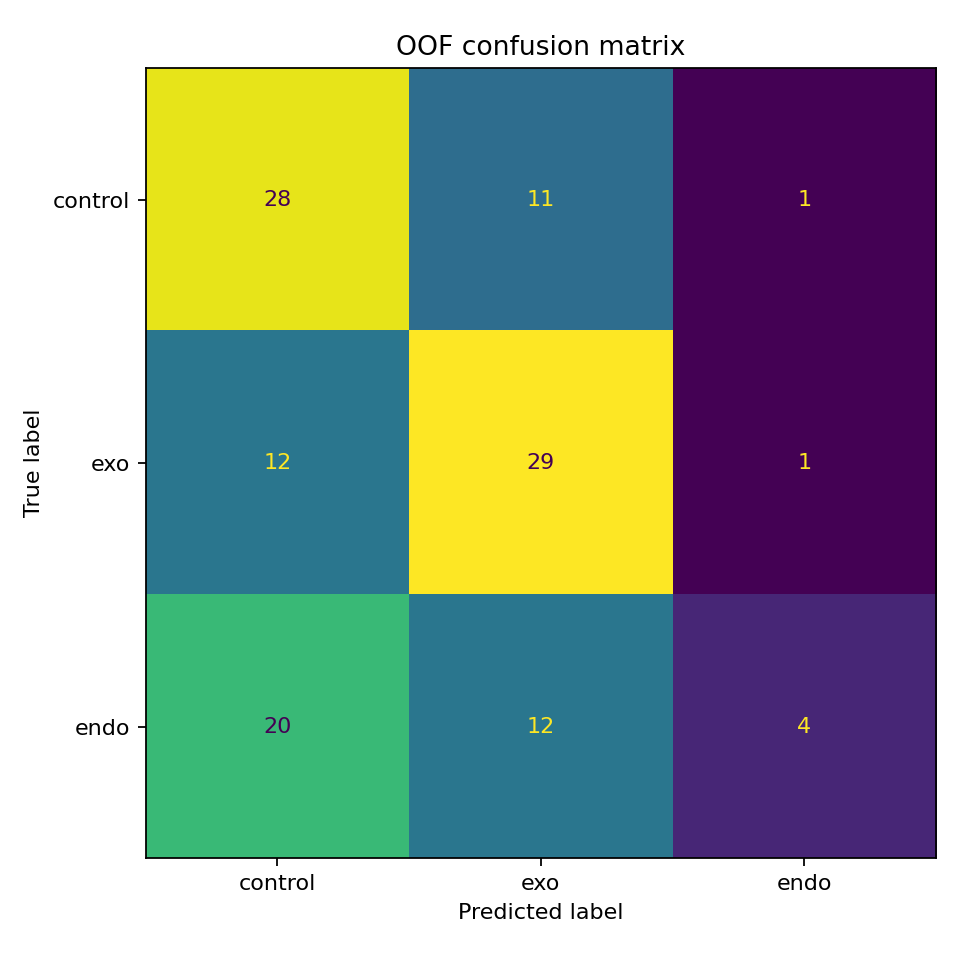

reviewing fold dir: /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/artifacts/raman_mil_train_and_results_2900/fold_0
training_history.png True


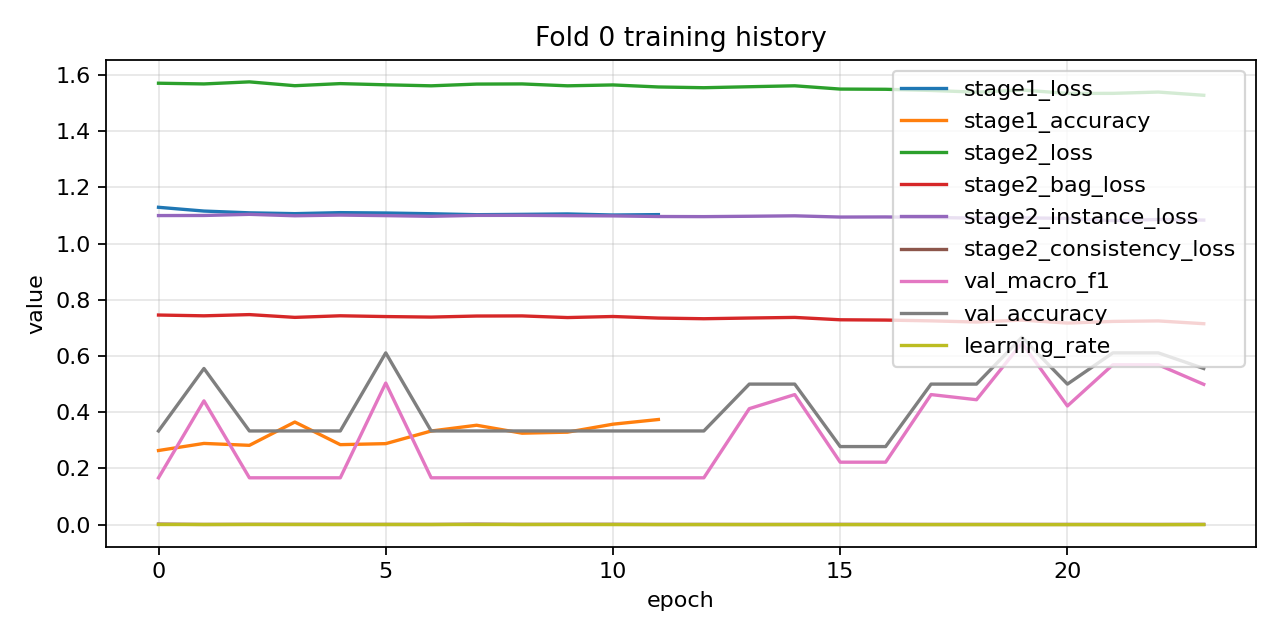

confusion_matrix.png True


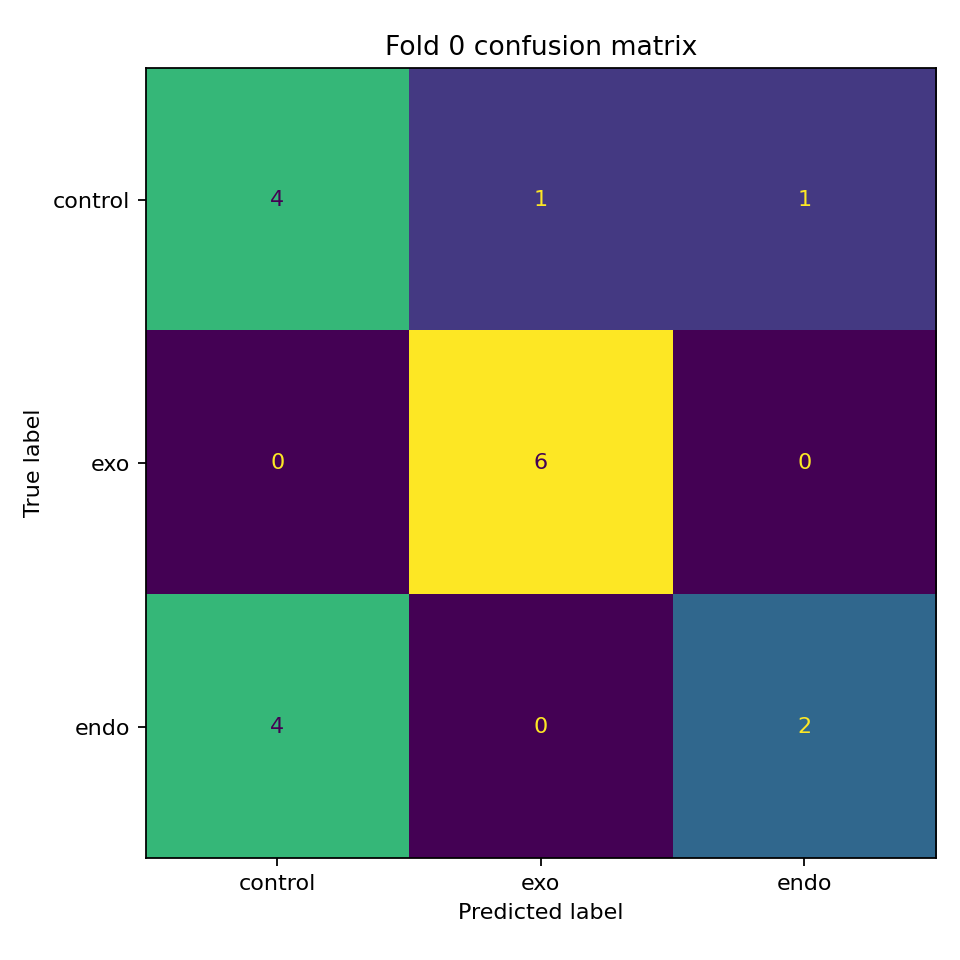

attention_weights.png True


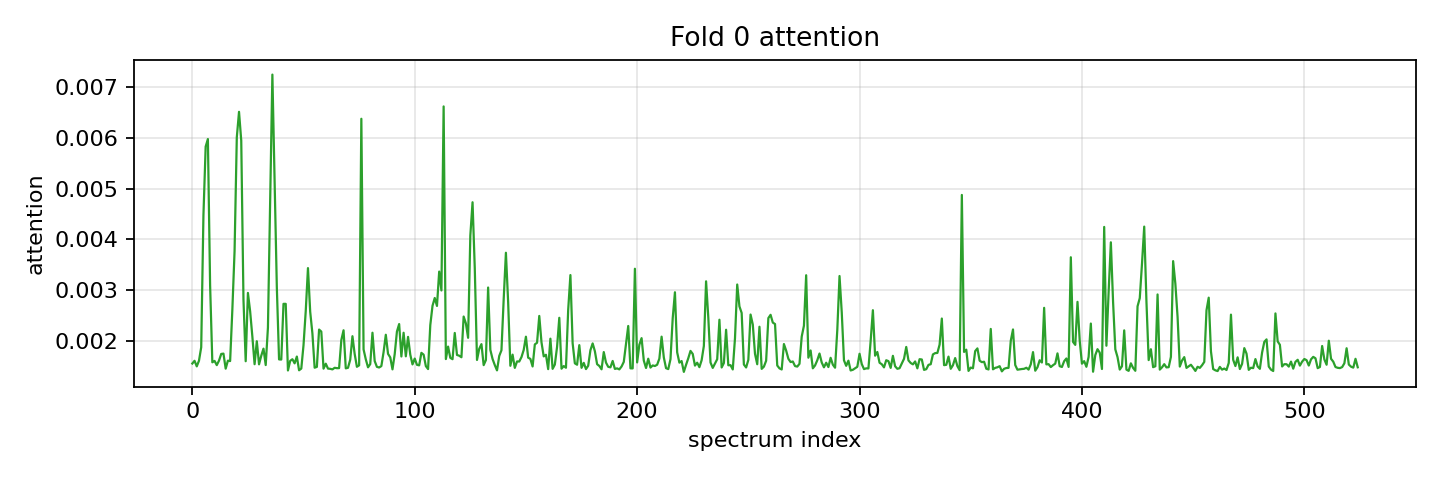

spectrum_attribution.png True


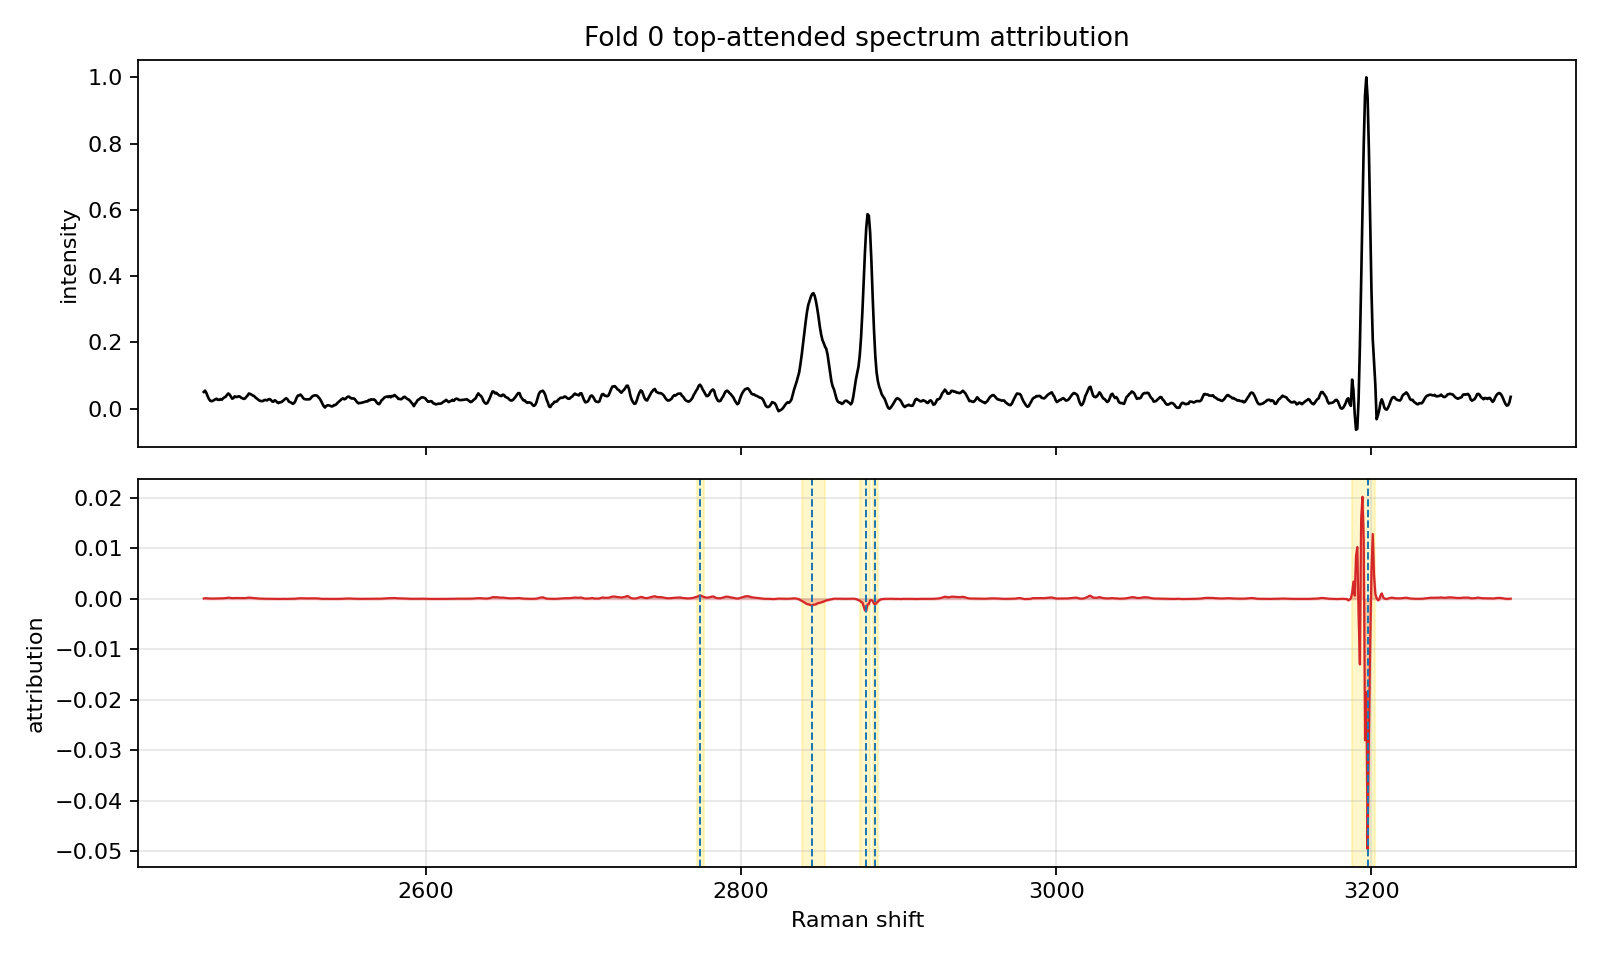

In [9]:
display(Image(filename=str(RESULTS_DIR / "oof_confusion_matrix.png")))

fold_dirs = sorted([p for p in RESULTS_DIR.glob("fold_*") if p.is_dir()])
if not fold_dirs:
    raise FileNotFoundError(f"No fold_* directories found in {RESULTS_DIR}")
fold_dir = fold_dirs[0]
print("reviewing fold dir:", fold_dir)

for image_name in [
    "training_history.png",
    "confusion_matrix.png",
    "attention_weights.png",
    "spectrum_attribution.png",
]:
    image_path = fold_dir / image_name
    print(image_name, image_path.exists())
    if image_path.exists():
        display(Image(filename=str(image_path)))

Глобальная OOF confusion matrix смешивает все ткани вместе. Следующий блок строит отдельные матрицы ошибок для `cortex`, `striatum` и `cerebellum`, чтобы отделить обычную межклассовую путаницу от tissue/domain shift. `cerebellum` интерпретируйте осторожно: в текущих данных эта область встречается только в `group 3`.



=== cortex ===
n maps: 54
macro_f1: 0.5392
accuracy: 0.6111


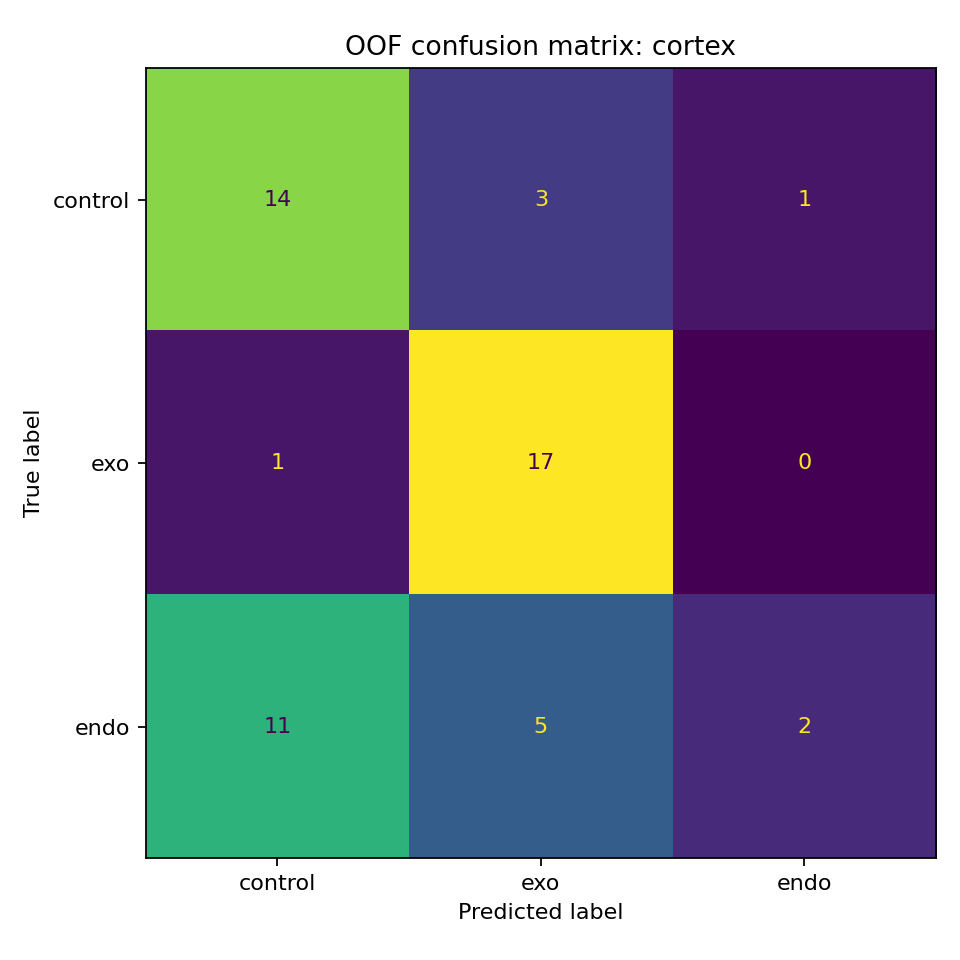


=== striatum ===
n maps: 36
macro_f1: 0.3988
accuracy: 0.5


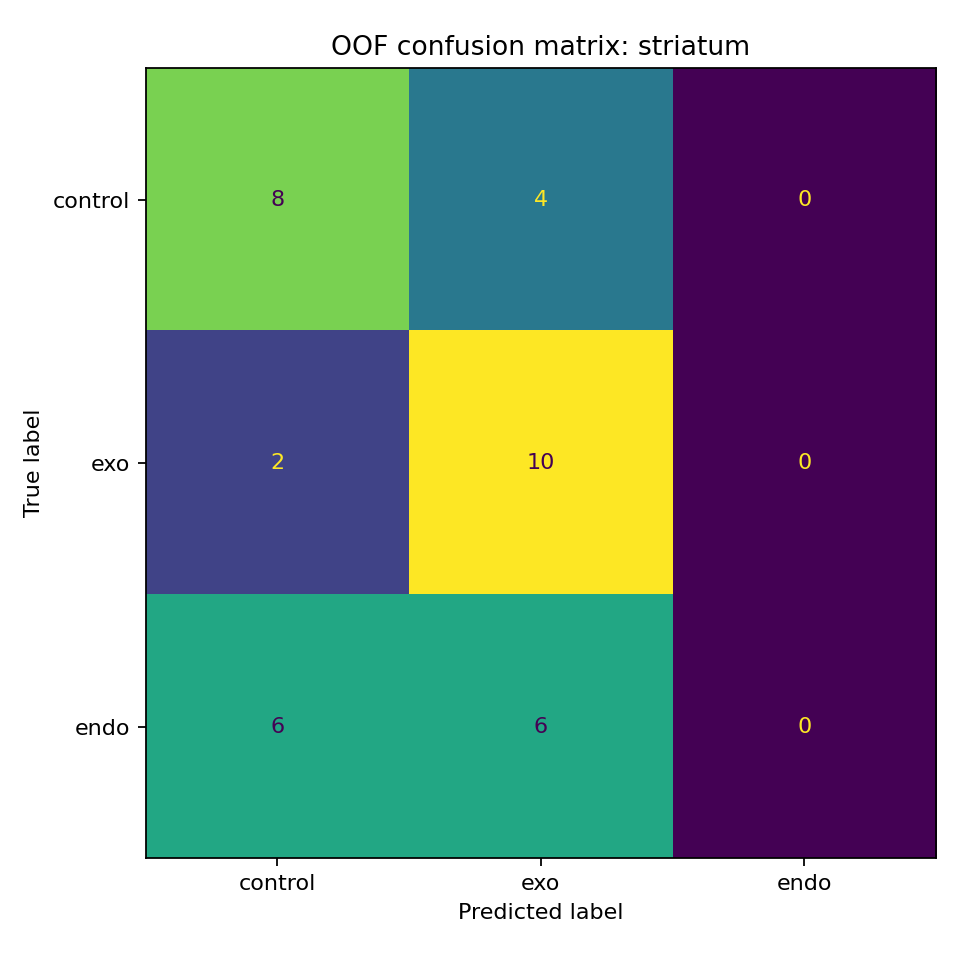


=== cerebellum ===
n maps: 28
macro_f1: 0.3612
accuracy: 0.3571


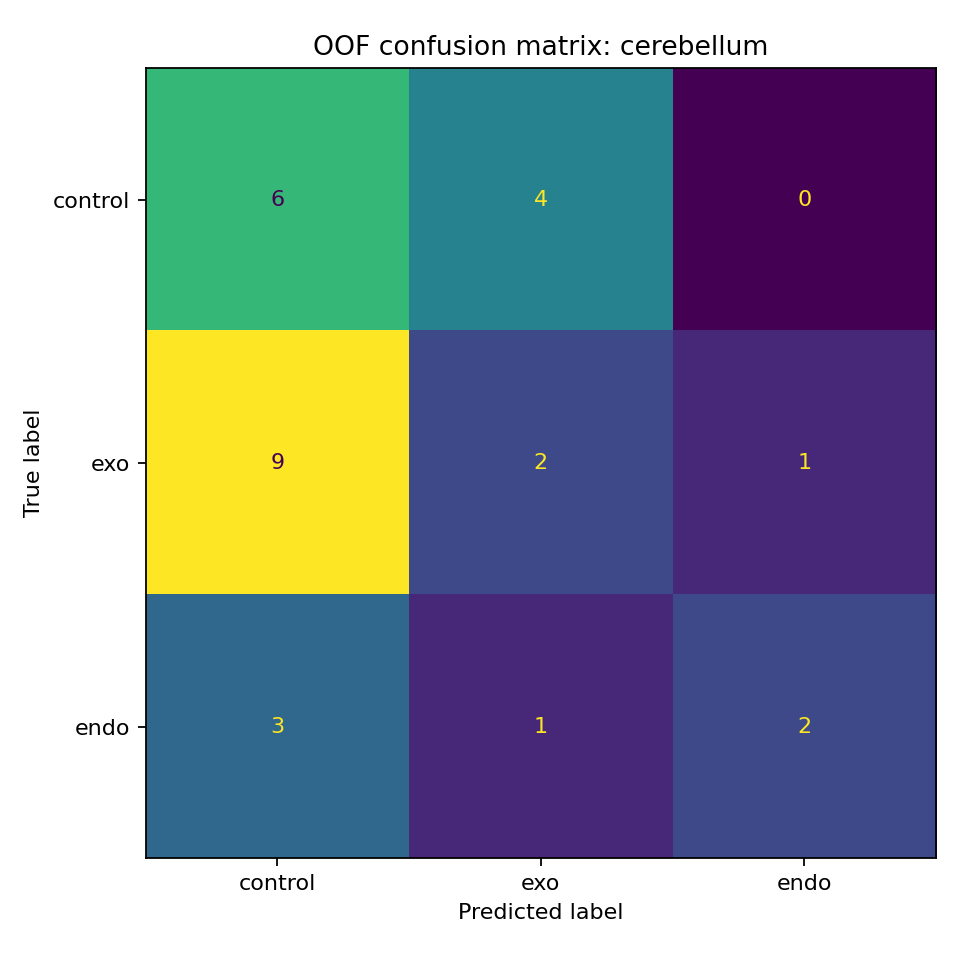

In [10]:
from sklearn.metrics import accuracy_score, f1_score

def parse_tissue_from_name(name: str) -> str:
    for tissue in ["cortex", "striatum", "cerebellum"]:
        if tissue in name:
            return tissue
    return "unknown"

tissue_eval_df = oof_df.copy()
tissue_eval_df["tissue"] = tissue_eval_df["name"].map(parse_tissue_from_name)

for tissue in ["cortex", "striatum", "cerebellum"]:
    tissue_df = tissue_eval_df.loc[tissue_eval_df["tissue"] == tissue].copy()
    print(f"\n=== {tissue} ===")
    if tissue_df.empty:
        print("No samples found for this tissue.")
        continue
    y_true_t = tissue_df["y_true"].to_numpy()
    y_pred_t = tissue_df["y_pred"].to_numpy()
    print("n maps:", len(tissue_df))
    print("macro_f1:", round(float(f1_score(y_true_t, y_pred_t, average="macro")), 4))
    print("accuracy:", round(float(accuracy_score(y_true_t, y_pred_t)), 4))
    output_path = RESULTS_DIR / f"oof_confusion_matrix_{tissue}.png"
    plot_confusion_matrix(y_true_t, y_pred_t, output_path, title=f"OOF confusion matrix: {tissue}")
    display(Image(filename=str(output_path)))


Что смотреть на графиках:

- `training_history.png`: не должно быть явных NaN и развала лоссов;
- `confusion_matrix.png`: распределение ошибок по классам на одном fold;
- `attention_weights.png`: как MIL распределяет важность между спектрами карты;
- `spectrum_attribution.png`: какие области спектра дали вклад в решение для выбранного класса.

In [11]:
fold_model_path = fold_dir / "best_model.pt"
trained_model, checkpoint = load_checkpoint(fold_model_path, map_location=device)
trained_model = trained_model.to(device)

print("checkpoint path:", fold_model_path)
print("checkpoint keys:", sorted(checkpoint.keys()))
print("saved common_nu len:", len(checkpoint["common_nu"]))
print(json.dumps(checkpoint["model_config"], ensure_ascii=True, indent=2))

checkpoint path: /home/yaroslav/progs/biohack/deeppick_mephi_2026/ml/artifacts/raman_mil_train_and_results_2900/fold_0/best_model.pt
checkpoint keys: ['common_nu', 'fold', 'label_mapping', 'metadata_coverage_warning', 'model_config', 'preprocess_kwargs', 'preprocess_mode', 'state_dict', 'train_config', 'train_tissue_counts', 'use_metadata', 'val_metrics', 'val_tissue_counts']
saved common_nu len: 1015
{
  "input_length": 1015,
  "num_classes": 3,
  "encoder_dim": 128,
  "stem_channels": 32,
  "branch_channels": 32,
  "metadata_vocab_size": 3,
  "metadata_dim": 8,
  "use_metadata": false,
  "dropout": 0.15,
  "attention_dim": 128,
  "encoder_chunk_size": 32,
  "norm_type": "group",
  "group_norm_groups": 8
}


Если эта ячейка отрабатывает, значит сохранение и повторная загрузка `best_model.pt` корректны и совместимы с текущей версией `torch`.

In [12]:
records_by_sample_id = {rec["sample_id"]: rec for rec in records}
selected_sample_id = int(oof_df.iloc[0]["sample_id"])
selected_record = records_by_sample_id[selected_sample_id]

eval_chunk_size = checkpoint.get("train_config", {}).get("eval_chunk_size", RUN_CONFIG.eval_chunk_size)

map_result = predict_map(
    model=trained_model,
    spectra=selected_record["spectra"],
    tissue_id=selected_record["tissue_id"],
    device=device,
    chunk_size=eval_chunk_size,
)

print("sample_id:", selected_record["sample_id"])
print("name:", selected_record["name"])
print("true class:", selected_record["target"])
print("pred class:", id2target[map_result["pred_class"]])
print("bag probs:", np.round(map_result["bag_probs"], 4))
print("attention length:", len(map_result["attention"]))

sample_id: 0
name: cortex_control_1group_633nm_center2900_obj100_power100_1s_5acc_map35x15_step2_place4_1.txt
true class: control
pred class: control
bag probs: [0.3863 0.2572 0.3565]
attention length: 525


Нормальный результат здесь: корректное имя карты, правдоподобный вектор вероятностей длины 3 и `attention length`, совпадающий с числом спектров в выбранной карте.

In [13]:
top_spec_idx = int(np.argmax(map_result["attention"]))
top_spectrum = selected_record["spectra"][top_spec_idx]

spectrum_result = predict_spectrum(
    model=trained_model,
    spectrum=top_spectrum,
    tissue_id=selected_record["tissue_id"],
    device=device,
)

print("top attended spectrum index:", top_spec_idx)
print("spectrum pred class:", id2target[spectrum_result["pred_class"]])
print("spectrum probs:", np.round(spectrum_result["probs"], 4))

top attended spectrum index: 36
spectrum pred class: exo
spectrum probs: [0.3244 0.3798 0.2958]


Это отдельная проверка режима single-spectrum inference. Несмотря на то что обучение weakly supervised и метка приходит на уровне всей карты, модель обязана выдавать предсказание и для одного спектра.

,start_idx,end_idx,start_nu,end_nu,peak_idx,peak_nu,score_sum,score_max
0,891,909,3187.729980,3202.451660,903,3197.544434,0.343776,0.057143
1,510,522,2876.121094,2885.935547,514,2879.392578,0.023977,0.003845
2,464,482,2838.499023,2853.220703,472,2845.041992,0.022267,0.001804
3,383,388,2772.251465,2776.340820,385,2773.887207,0.004226,0.000849
4,316,321,2717.454102,2721.543457,317,2718.271973,0.004011,0.000732


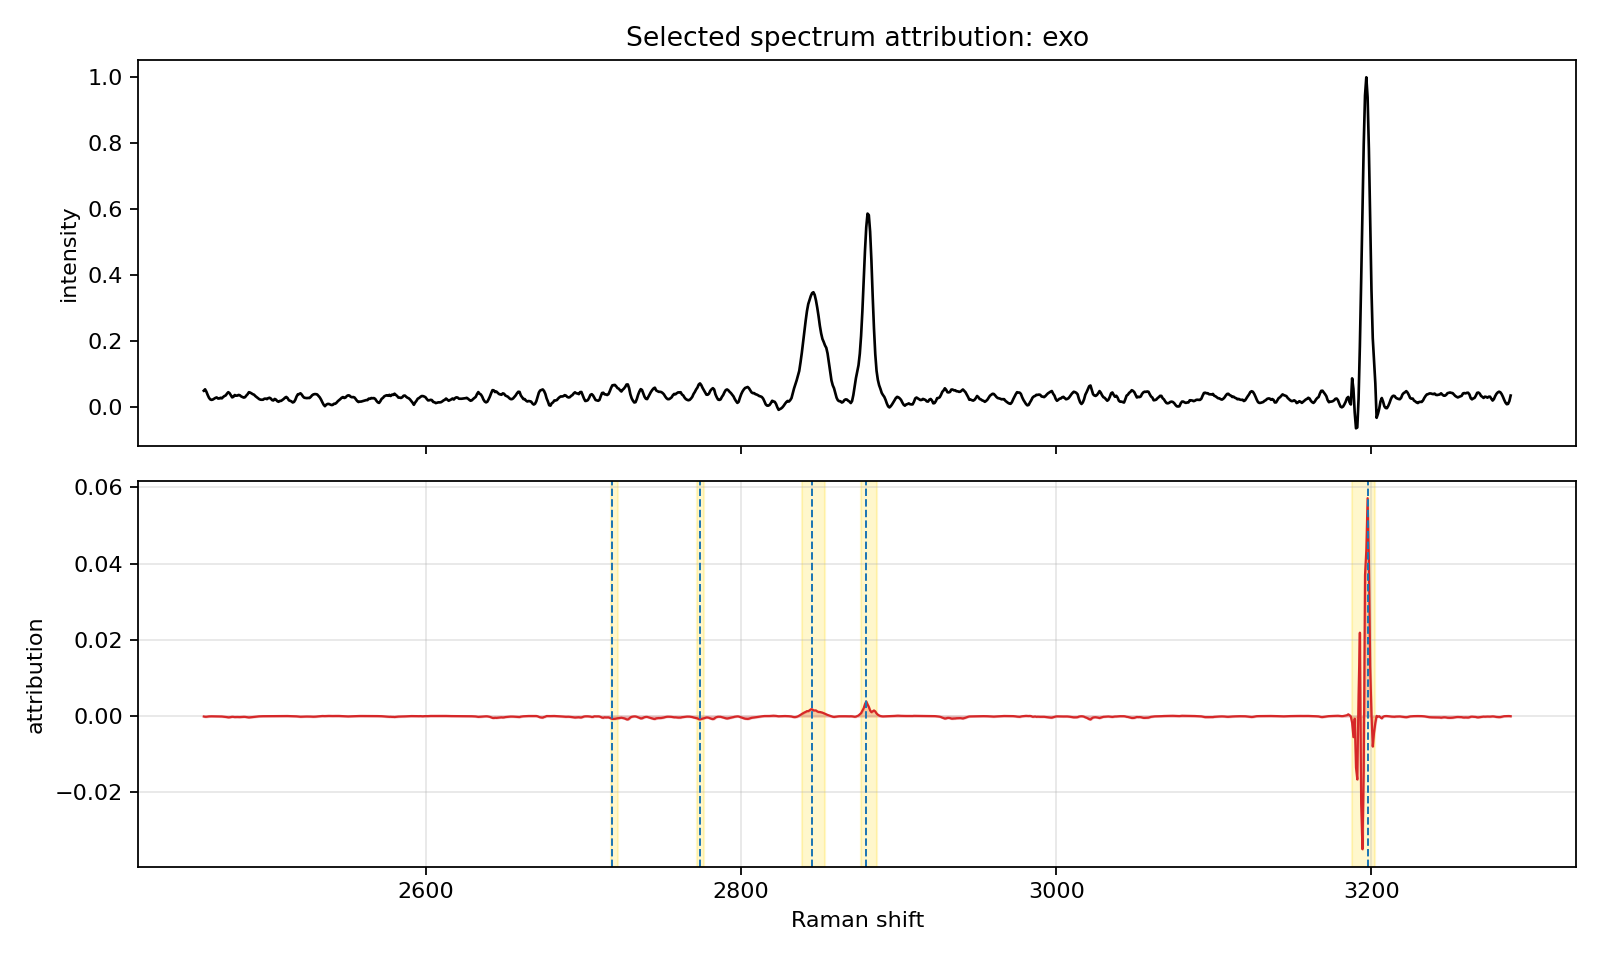

In [14]:
explanation = explain_spectrum(
    model=trained_model,
    spectrum=top_spectrum,
    common_nu=np.asarray(checkpoint["common_nu"], dtype=np.float32),
    tissue_id=selected_record["tissue_id"],
    target_class=spectrum_result["pred_class"],
    device=device,
)

display(pd.DataFrame(explanation["intervals"]))

inline_attr_path = RESULTS_DIR / "inline_selected_spectrum_attribution.png"
plot_spectrum_attribution(
    common_nu=np.asarray(checkpoint["common_nu"], dtype=np.float32),
    spectrum=explanation["spectrum"],
    attribution=explanation["attribution"],
    intervals=explanation["intervals"],
    output_path=inline_attr_path,
    title=f"Selected spectrum attribution: {id2target[explanation['target_class']]}",
)
display(Image(filename=str(inline_attr_path)))

Интерпретация строится вдоль оси Raman shift. Таблица `intervals` показывает наиболее важные спектральные интервалы и пики, а график ниже совмещает исходный спектр и attribution по частотам.

## 2. Quick troubleshooting

- Если обучение слишком долгое, переключите `RUN_CONFIG = quick_debug_config`.
- Если даже так не хватает памяти GPU, уменьшите `max_spectra_per_map`, `batch_size` и `encoder_chunk_size` ещё сильнее, например до `96 / 2 / 32`.
- Если train уже завершился и артефакты на диске есть, можно не перезапускать обучение, а начать с ячейки загрузки `summary.json` или `best_model.pt`.
- Если notebook-кернел запущен не из `.venv`, сначала выполните `uv sync` и выберите kernel из текущего проекта.